# Time Warping

## 1. Imports

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF

## 2. Helpers de segmentation comportementale

Rôle:

Cette cellule regroupe les fonctions de base qui existaient déjà avant le time warping et qui servent à :

- détecter la direction dangereuse
- découper les laps
- étiqueter danger/safe
- estimer la position du puff
- sélectionner les neurones

In [2]:
def get_danger_direction(event_run):
    """
    Determine danger direction from event_run.
    Returns +1 (left->right), -1 (right->left), or 0 if undefined.
    """
    event_run = np.squeeze(event_run)

    reward_idx = np.where((event_run == 2) | (event_run == 3))[0]
    directions = []

    for i in range(len(reward_idx) - 1):
        i0, i1 = reward_idx[i], reward_idx[i+1]
        r0 = event_run[i0]
        r1 = event_run[i1]

        # Check if danger occurred between the two rewards
        if np.any(event_run[i0:i1] == 1):
            if r0 == 3 and r1 == 2:
                directions.append(+1)  # left -> right
            elif r0 == 2 and r1 == 3:
                directions.append(-1)  # right -> left

    if len(directions) == 0:
        return 0

    return int(np.sign(np.mean(directions)))


def extract_laps(
    pos, event, dt_ms,
    left=0.25, right=0.85,
    cancel_on_backtrack=True,
    eps=1e-12
):
    x = np.asarray(pos[0], dtype=float)
    ev = np.asarray(event[0]).astype(int)
    n = len(x)
    assert len(ev) == n

    zone = np.full(n, "C", dtype="<U1")
    zone[x <= left + eps] = "L"
    zone[x >= right - eps] = "R"
    zone[np.isnan(x)] = "N"

    laps = []
    state = None
    start_idx = None

    for i in range(n):
        if zone[i] == "N":
            continue

        if state is None:
            if i > 0:
                j = i - 1
                while j >= 0 and zone[j] == "N":
                    j -= 1
                if j >= 0 and zone[j] == "L" and zone[i] == "C":
                    state = "LR"; start_idx = i
                elif j >= 0 and zone[j] == "R" and zone[i] == "C":
                    state = "RL"; start_idx = i

        else:
            if state == "LR":
                if cancel_on_backtrack and zone[i] == "L":
                    state = None; start_idx = None; continue

                if zone[i] == "R":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": +1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

            elif state == "RL":
                if cancel_on_backtrack and zone[i] == "R":
                    state = None; start_idx = None; continue

                if zone[i] == "L":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": -1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

    return laps


def label_laps_with_danger(laps, danger_dir):
    for lap in laps:
        lap["is_danger"] = (lap["dir"] == danger_dir)
    return laps


def estimate_pos_puff_from_run(pos_run, event_run):
    """Median x position during puff bins (event==1) in RUN."""
    x_run = np.asarray(pos_run[0], dtype=float)
    ev = np.asarray(event_run[0]).astype(int)
    puff_idx = np.where(ev == 1)[0]
    if puff_idx.size == 0:
        raise ValueError("No puff bins found in event.run == 1. Cannot estimate pos_puff.")
    return float(np.nanmedian(x_run[puff_idx]))


def select_neurons(metadata, use_regions="HB", excit_only=True):
    """
    metadata columns (0-based):
      col2: region  (1 dHPC, 2 rBLA, 3 lBLA, 4 Pir)
      col3: type    (1 pyramidal, 2 interneuron)
    """
    meta = np.asarray(metadata)
    region = meta[:, 2].astype(int)
    ntype  = meta[:, 3].astype(int)

    keep = np.ones(meta.shape[0], dtype=bool)
    if excit_only:
        keep &= (ntype == 1)

    is_hpc = (region == 1)
    is_bla = np.isin(region, [2, 3])
    is_hb  = is_hpc | is_bla

    if use_regions == "HPC":
        keep &= is_hpc
    elif use_regions == "BLA":
        keep &= is_bla
    elif use_regions == "HB":
        keep &= is_hb
    else:
        raise ValueError("use_regions must be 'HPC', 'BLA', or 'HB'")

    idx = np.where(keep)[0]
    idx_hpc = np.where((ntype == 1) & is_hpc)[0]
    idx_bla = np.where((ntype == 1) & is_bla)[0]
    return idx, idx_hpc, idx_bla

## 3. Fonctions de time warping

Rôle:

Cette cellule contient uniquement les trois briques de warping utiles.

- warp_spike_segment_piecewise : warping temporel centré sur le puff
- warp_position_piecewise : même transformation, mais appliquée aux positions pour pouvoir diagnostiquer ce que représente chaque bin warpé
- warp_spike_segment_by_position : warping spatial, où l’on interpole directement sur une grille de positions commune

In [3]:
def warp_spike_segment_piecewise(seg_spk, seg_x, pos_puff, n_bins=31):
    """
    Piecewise warping aligned on the puff position.

    seg_spk : array (neurons x Tseg)
    seg_x   : array (Tseg,)
    pos_puff: scalar
    n_bins  : preferably odd

    Returns
    -------
    warped : array (neurons x n_bins)

    The central bin corresponds to the time bin closest to pos_puff.
    """

    seg_spk = np.asarray(seg_spk, dtype=float)
    seg_x = np.asarray(seg_x, dtype=float)

    n_neurons, Tseg = seg_spk.shape

    if Tseg < 3:
        raise ValueError("Segment too short for piecewise warping.")

    if n_bins < 3:
        raise ValueError("n_bins must be at least 3.")

    anchor = int(np.argmin(np.abs(seg_x - pos_puff)))

    if anchor == 0 or anchor == Tseg - 1:
        raise ValueError("Anchor too close to segment boundary.")

    n_left = n_bins // 2
    n_right = n_bins // 2
    has_center = (n_bins % 2 == 1)

    left_idx = np.arange(0, anchor + 1)   # includes anchor
    right_idx = np.arange(anchor, Tseg)   # includes anchor

    left_spk = seg_spk[:, left_idx]
    right_spk = seg_spk[:, right_idx]

    # left side -> n_left + 1 bins
    t_left_old = np.linspace(0.0, 1.0, left_spk.shape[1])
    t_left_new = np.linspace(0.0, 1.0, n_left + 1)

    warped_left = np.zeros((n_neurons, n_left + 1), dtype=float)
    for n in range(n_neurons):
        warped_left[n] = np.interp(t_left_new, t_left_old, left_spk[n])

    # right side -> n_right + 1 bins
    t_right_old = np.linspace(0.0, 1.0, right_spk.shape[1])
    t_right_new = np.linspace(0.0, 1.0, n_right + 1)

    warped_right = np.zeros((n_neurons, n_right + 1), dtype=float)
    for n in range(n_neurons):
        warped_right[n] = np.interp(t_right_new, t_right_old, right_spk[n])

    if has_center:
        center_bin = seg_spk[:, anchor:anchor+1]
        warped = np.concatenate(
            [warped_left[:, :-1], center_bin, warped_right[:, 1:]],
            axis=1
        )
    else:
        warped = np.concatenate(
            [warped_left[:, :-1], warped_right],
            axis=1
        )

    return warped

def warp_position_piecewise(seg_x, pos_puff, n_bins=31):
    seg_x = np.asarray(seg_x, dtype=float)
    anchor = int(np.argmin(np.abs(seg_x - pos_puff)))

    if anchor == 0 or anchor == len(seg_x) - 1:
        raise ValueError("Anchor too close to boundary.")

    n_left = n_bins // 2
    n_right = n_bins // 2

    left = seg_x[:anchor+1]
    right = seg_x[anchor:]

    t_left_old = np.linspace(0, 1, len(left))
    t_left_new = np.linspace(0, 1, n_left + 1)

    t_right_old = np.linspace(0, 1, len(right))
    t_right_new = np.linspace(0, 1, n_right + 1)

    left_w = np.interp(t_left_new, t_left_old, left)
    right_w = np.interp(t_right_new, t_right_old, right)

    return np.concatenate([left_w[:-1], [seg_x[anchor]], right_w[1:]])

def warp_spike_segment_by_position(seg_spk, seg_x, x_new):
    seg_spk = np.asarray(seg_spk, dtype=float)
    seg_x = np.asarray(seg_x, dtype=float)

    if seg_spk.shape[1] != len(seg_x):
        raise ValueError("seg_spk and seg_x length mismatch.")

    keep = ~np.isnan(seg_x)
    seg_x = seg_x[keep]
    seg_spk = seg_spk[:, keep]

    if len(seg_x) < 2:
        raise ValueError("Segment too short for spatial interpolation.")

    if seg_x[0] > seg_x[-1]:
        seg_x = seg_x[::-1]
        seg_spk = seg_spk[:, ::-1]

    uniq_x, uniq_idx = np.unique(seg_x, return_index=True)
    seg_spk = seg_spk[:, uniq_idx]

    if len(uniq_x) < 2:
        raise ValueError("Not enough distinct positions for interpolation.")

    warped = np.zeros((seg_spk.shape[0], len(x_new)), dtype=float)
    for n in range(seg_spk.shape[0]):
        warped[n] = np.interp(x_new, uniq_x, seg_spk[n])

    return warped


## 4. Extraction commune des données et des laps

Rôle :

Cette cellule sert à factoriser tout ce qui est répété partout : chargement des structures MATLAB, extraction des laps, calcul de pos_puff, bornes de la puff-zone, etc.

In [4]:
def get_laps_and_common_info(
    data_full,
    session="run",
    dt_ms=50,
    corridor_left=0.25,
    corridor_right=0.85,
    halfwidth_cm=20,
    track_length_cm=180,
    cancel_on_backtrack=True,
    eps=1e-12,
):
    spk_sess = data_full["spik"][session][0, 0].astype(float)
    pos_sess = data_full["posit"][session][0, 0].astype(float)
    event_sess = data_full["event"][session][0, 0]

    pos_run = data_full["posit"]["run"][0, 0].astype(float)
    event_run = data_full["event"]["run"][0, 0]

    danger_dir = get_danger_direction(event_run)
    pos_puff = estimate_pos_puff_from_run(pos_run, event_run)

    delta = halfwidth_cm / track_length_cm
    left_win = pos_puff - delta
    right_win = pos_puff + delta

    laps = extract_laps(
        pos_sess, event_sess, dt_ms,
        left=corridor_left, right=corridor_right,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps
    )
    laps = label_laps_with_danger(laps, danger_dir)

    return {
        "spk_sess": spk_sess,
        "pos_sess": pos_sess,
        "event_sess": event_sess,
        "laps": laps,
        "danger_dir": danger_dir,
        "pos_puff": pos_puff,
        "left_win": left_win,
        "right_win": right_win,
        "dt_ms": dt_ms,
    }

## 5. Construction des représentations (tenseur et matrices par neurone)

Rôle :

Cette cellule regroupe les fonctions qui fabriquent les objets analysables.

In [5]:
def build_warped_lap_tensor(
    data_full,
    session="run",
    dt_ms=50,
    use_regions="HB",
    excit_only=True,
    corridor_left=0.25,
    corridor_right=0.85,
    restrict_to_puff_zone=False,
    halfwidth_cm=20,
    track_length_cm=180,
    n_time_bins=31,
    warp_mode="puff_time",   # "puff_time" or "position"
    cancel_on_backtrack=True,
    min_bins_per_lap=5,
    eps=1e-12,
):
    metadata = data_full["metadata"]

    spk_sess = data_full["spik"][session][0, 0].astype(float)
    pos_sess = data_full["posit"][session][0, 0].astype(float)
    event_sess = data_full["event"][session][0, 0]

    pos_run = data_full["posit"]["run"][0, 0].astype(float)
    event_run = data_full["event"]["run"][0, 0]

    danger_dir = get_danger_direction(event_run)
    pos_puff = estimate_pos_puff_from_run(pos_run, event_run)

    delta = halfwidth_cm / track_length_cm
    left_win = pos_puff - delta
    right_win = pos_puff + delta

    laps = extract_laps(
        pos_sess, event_sess, dt_ms,
        left=corridor_left, right=corridor_right,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps
    )
    laps = label_laps_with_danger(laps, danger_dir)

    neuron_idx, idx_hpc, idx_bla = select_neurons(
        metadata, use_regions=use_regions, excit_only=excit_only
    )

    x = np.asarray(pos_sess[0], dtype=float)

    warped_laps = []
    lap_labels = []
    lap_ids = []
    warped_positions = []

    if restrict_to_puff_zone:
        x_new = np.linspace(left_win, right_win, n_time_bins)
    else:
        x_new = np.linspace(corridor_left, corridor_right, n_time_bins)

    for lap in laps:
        idx = lap["idx"]

        if restrict_to_puff_zone:
            idx = idx[
                (~np.isnan(x[idx])) &
                (x[idx] >= left_win - eps) &
                (x[idx] <= right_win + eps)
            ]

        if idx.size < min_bins_per_lap:
            continue

        seg_spk = spk_sess[neuron_idx][:, idx]
        seg_x = x[idx]

        try:
            if warp_mode == "puff_time":
                warped = warp_spike_segment_piecewise(seg_spk, seg_x, pos_puff, n_bins=n_time_bins)
                x_warped = warp_position_piecewise(seg_x, pos_puff, n_bins=n_time_bins)

            elif warp_mode == "position":
                warped = warp_spike_segment_by_position(seg_spk, seg_x, x_new=x_new)
                x_warped = x_new.copy()

            else:
                raise ValueError("warp_mode must be 'puff_time' or 'position'")

        except ValueError:
            continue

        warped_laps.append(warped)
        lap_labels.append(int(lap["is_danger"]))
        lap_ids.append(lap["lap"])
        warped_positions.append(x_warped)

    if len(warped_laps) == 0:
        raise ValueError("No laps kept after warping step.")

    X = np.stack(warped_laps, axis=2)                    # neurons x time x laps
    warped_positions = np.stack(warped_positions, axis=1)  # time x laps

    info = {
        "session": session,
        "danger_dir": danger_dir,
        "pos_puff": pos_puff,
        "window": (left_win, right_win),
        "n_laps_total": len(laps),
        "n_laps_kept": X.shape[2],
        "lap_ids": np.array(lap_ids),
        "lap_labels": np.array(lap_labels),
        "neuron_idx": neuron_idx,
        "idx_hpc": idx_hpc,
        "idx_bla": idx_bla,
        "restrict_to_puff_zone": restrict_to_puff_zone,
        "warp_mode": warp_mode,
        "x_new": x_new if warp_mode == "position" else None,
        "warped_positions": warped_positions,
    }

    return X, info

def build_nonwarped_matrix_for_neuron(
    data_full,
    neuron_idx,
    session="run",
    dt_ms=50,
    halfwidth_cm=20,
    track_length_cm=180,
    corridor_left=0.25,
    corridor_right=0.85,
    t_before_s=1.0,
    t_after_s=1.0,
    cancel_on_backtrack=True,
    eps=1e-12,
):
    info = get_laps_and_common_info(
        data_full=data_full,
        session=session,
        dt_ms=dt_ms,
        corridor_left=corridor_left,
        corridor_right=corridor_right,
        halfwidth_cm=halfwidth_cm,
        track_length_cm=track_length_cm,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps,
    )

    spk_sess = info["spk_sess"]
    x = np.asarray(info["pos_sess"][0], dtype=float)
    laps = info["laps"]
    pos_puff = info["pos_puff"]
    left_win = info["left_win"]
    right_win = info["right_win"]

    n_before = int(round(t_before_s * 1000 / dt_ms))
    n_after = int(round(t_after_s * 1000 / dt_ms))
    n_cols = n_before + 1 + n_after

    rows = []
    labels = []
    lap_ids = []

    for lap in laps:
        idx = lap["idx"]

        # restrict to puff zone
        idx = idx[
            (~np.isnan(x[idx])) &
            (x[idx] >= left_win - eps) &
            (x[idx] <= right_win + eps)
        ]

        if idx.size < 3:
            continue

        # anchor = closest position to puff
        local_anchor = int(np.argmin(np.abs(x[idx] - pos_puff)))
        anchor_global = idx[local_anchor]

        row = np.full(n_cols, np.nan, dtype=float)

        # desired global indices around anchor
        wanted = np.arange(anchor_global - n_before, anchor_global + n_after + 1)

        # fill only where indices exist in session and belong to the puff-zone segment
        valid_mask = np.isin(wanted, idx)
        valid_wanted = wanted[valid_mask]

        row[np.where(valid_mask)[0]] = spk_sess[neuron_idx, valid_wanted]

        rows.append(row)
        labels.append(int(lap["is_danger"]))
        lap_ids.append(lap["lap"])

    if len(rows) == 0:
        raise ValueError("No laps available for non-warped matrix.")

    M = np.vstack(rows)  # laps x time
    t_axis = np.arange(-n_before, n_after + 1) * dt_ms / 1000.0

    return M, np.array(labels), np.array(lap_ids), t_axis


def build_warped_matrix_for_neuron(
    data_full,
    neuron_idx,
    session="run",
    dt_ms=50,
    halfwidth_cm=20,
    track_length_cm=180,
    corridor_left=0.25,
    corridor_right=0.85,
    n_time_bins=31,
    warp_mode="puff_time",   # "puff_time" or "position"
    cancel_on_backtrack=True,
    eps=1e-12,
):
    info = get_laps_and_common_info(
        data_full=data_full,
        session=session,
        dt_ms=dt_ms,
        corridor_left=corridor_left,
        corridor_right=corridor_right,
        halfwidth_cm=halfwidth_cm,
        track_length_cm=track_length_cm,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps,
    )

    spk_sess = info["spk_sess"]
    x = np.asarray(info["pos_sess"][0], dtype=float)
    laps = info["laps"]
    pos_puff = info["pos_puff"]
    left_win = info["left_win"]
    right_win = info["right_win"]

    x_new = np.linspace(left_win, right_win, n_time_bins)

    rows = []
    labels = []
    lap_ids = []

    for lap in laps:
        idx = lap["idx"]

        idx = idx[
            (~np.isnan(x[idx])) &
            (x[idx] >= left_win - eps) &
            (x[idx] <= right_win + eps)
        ]

        if idx.size < 3:
            continue

        seg_spk = spk_sess[neuron_idx:neuron_idx+1, idx]  # 1 x T
        seg_x = x[idx]

        try:
            if warp_mode == "puff_time":
                warped = warp_spike_segment_piecewise(seg_spk, seg_x, pos_puff, n_bins=n_time_bins)
            elif warp_mode == "position":
                warped = warp_spike_segment_by_position(seg_spk, seg_x, x_new=x_new)
            else:
                raise ValueError("warp_mode must be 'puff_time' or 'position'")
        except ValueError:
            continue

        rows.append(warped[0])
        labels.append(int(lap["is_danger"]))
        lap_ids.append(lap["lap"])

    if len(rows) == 0:
        raise ValueError(f"No laps available for warp_mode={warp_mode}.")

    M = np.vstack(rows)  # laps x time
    return M, np.array(labels), np.array(lap_ids)


## 6. Visualisations du warping

**Rôle :**

Cette cellule contient les figures qui servent à comprendre ce que fait le warping.

In [6]:
def plot_warped_bin_positions(info):
    Xpos = info["warped_positions"]   # time x laps
    plt.figure(figsize=(8, 4))
    plt.boxplot([Xpos[t, :] for t in range(Xpos.shape[0])], showfliers=False)
    plt.axvline(Xpos.shape[0]//2 + 1, color="red", linestyle="--")
    plt.xlabel("Warped bin")
    plt.ylabel("Position")
    plt.title("Position represented by each warped bin across laps")
    plt.show()

def sort_rows_by_label(M, labels, lap_ids):
    order = np.argsort(labels)   # safe(0) then danger(1)
    return M[order], labels[order], lap_ids[order]

## 7. Visualisation type Pellegrino

**Rôle :**

Cette cellule regroupe la visualisation neurone-par-neurone, avant et après warping.


**Explication :**

Cette cellule produit les trois panneaux :

- non warpé
- warpé puff
- warpé position

C’est probablement la visualisation la plus importante à ce stade, car elle montre concrètement l’effet du warping sur l’activité neuronale.

In [7]:
def plot_three_pellegrino_style(
    data_full,
    neuron_idx,
    session="run",
    dt_ms=50,
    halfwidth_cm=20,
    track_length_cm=180,
    corridor_left=0.25,
    corridor_right=0.85,
    t_before_s=1.0,
    t_after_s=1.0,
    n_time_bins=31,
    cancel_on_backtrack=True,
    eps=1e-12,
    rat_name="Rat",
):
    # non-warped
    M0, y0, lap0, t_axis = build_nonwarped_matrix_for_neuron(
        data_full=data_full,
        neuron_idx=neuron_idx,
        session=session,
        dt_ms=dt_ms,
        halfwidth_cm=halfwidth_cm,
        track_length_cm=track_length_cm,
        corridor_left=corridor_left,
        corridor_right=corridor_right,
        t_before_s=t_before_s,
        t_after_s=t_after_s,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps,
    )
    M0, y0, lap0 = sort_rows_by_label(M0, y0, lap0)

    # puff-only warp
    M1, y1, lap1 = build_warped_matrix_for_neuron(
        data_full=data_full,
        neuron_idx=neuron_idx,
        session=session,
        dt_ms=dt_ms,
        halfwidth_cm=halfwidth_cm,
        track_length_cm=track_length_cm,
        corridor_left=corridor_left,
        corridor_right=corridor_right,
        n_time_bins=n_time_bins,
        warp_mode="puff_time",
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps,
    )
    M1, y1, lap1 = sort_rows_by_label(M1, y1, lap1)

    # position warp
    M2, y2, lap2 = build_warped_matrix_for_neuron(
        data_full=data_full,
        neuron_idx=neuron_idx,
        session=session,
        dt_ms=dt_ms,
        halfwidth_cm=halfwidth_cm,
        track_length_cm=track_length_cm,
        corridor_left=corridor_left,
        corridor_right=corridor_right,
        n_time_bins=n_time_bins,
        warp_mode="position",
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps,
    )
    M2, y2, lap2 = sort_rows_by_label(M2, y2, lap2)

    # common color scale for fair comparison
    vmin = np.nanmin([np.nanmin(M0), np.nanmin(M1), np.nanmin(M2)])
    vmax = np.nanmax([np.nanmax(M0), np.nanmax(M1), np.nanmax(M2)])

    cmap_obj = plt.cm.get_cmap("magma").copy()
    cmap_obj.set_bad(color="black")

    fig, axes = plt.subplots(3, 1, figsize=(6, 10), constrained_layout=True)

    # non-warped
    im0 = axes[0].imshow(M0, aspect="auto", cmap=cmap_obj, interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[0].axvline(np.where(np.isclose(t_axis, 0))[0][0], color="white", linestyle="--", linewidth=1)
    xticks0 = np.linspace(0, M0.shape[1]-1, 5).astype(int)
    axes[0].set_xticks(xticks0)
    axes[0].set_xticklabels([f"{t_axis[i]:.2f}" for i in xticks0])
    axes[0].set_title(f"{rat_name} — neurone {neuron_idx} — non warpé")
    axes[0].set_xlabel("Temps autour du puff (s)")
    axes[0].set_ylabel("Laps")

    n_safe0 = np.sum(y0 == 0)
    if 0 < n_safe0 < len(y0):
        axes[0].axhline(n_safe0 - 0.5, color="cyan", linewidth=1)

    # puff-time
    im1 = axes[1].imshow(M1, aspect="auto", cmap=cmap_obj, interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[1].axvline(M1.shape[1] // 2, color="white", linestyle="--", linewidth=1)
    axes[1].set_title(f"{rat_name} — neurone {neuron_idx} — warpé puff")
    axes[1].set_xlabel("Temps normalisé")
    axes[1].set_ylabel("Laps")

    n_safe1 = np.sum(y1 == 0)
    if 0 < n_safe1 < len(y1):
        axes[1].axhline(n_safe1 - 0.5, color="cyan", linewidth=1)

    # position
    im2 = axes[2].imshow(M2, aspect="auto", cmap=cmap_obj, interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[2].axvline(M2.shape[1] // 2, color="white", linestyle="--", linewidth=1)
    axes[2].set_title(f"{rat_name} — neurone {neuron_idx} — warpé position")
    axes[2].set_xlabel("Position normalisée")
    axes[2].set_ylabel("Laps")

    n_safe2 = np.sum(y2 == 0)
    if 0 < n_safe2 < len(y2):
        axes[2].axhline(n_safe2 - 0.5, color="cyan", linewidth=1)

    fig.colorbar(im2, ax=axes, label="Activité")
    plt.show()

## 8. Préparation NMF et factorisation

**Rôle :**

Cette cellule regroupe toutes les fonctions utiles pour passer du tenseur à la NMF.

**Explication :**

Cette cellule te permet de prendre ton tenseur et de le transformer en différentes matrices selon la coupe choisie :

- neurones
- temps
- laps

Puis de lancer la NMF.

In [8]:
def tensor_to_neuron_slicing(X):
    """
    X: neurons x time x laps
    returns matrix neurons x (time*laps)
    """
    N, T, L = X.shape
    return X.reshape(N, T * L)


def tensor_to_time_slicing(X):
    """
    returns matrix time x (neurons*laps)
    """
    N, T, L = X.shape
    return np.transpose(X, (1, 0, 2)).reshape(T, N * L)


def tensor_to_lap_slicing(X):
    """
    returns matrix laps x (neurons*time)
    """
    N, T, L = X.shape
    return np.transpose(X, (2, 0, 1)).reshape(L, N * T)


def run_nmf(M, n_components=5, seed=0, max_iter=1000):
    """
    M must be nonnegative.
    Returns W, H, nmf_model
    with M ≈ W @ H
    """
    M = np.asarray(M, dtype=float)

    if np.any(M < 0):
        raise ValueError("NMF requires nonnegative data.")

    model = NMF(
        n_components=n_components,
        init="nndsvda",
        random_state=seed,
        max_iter=max_iter
    )
    W = model.fit_transform(M)
    H = model.components_
    return W, H, model

## 9. Chargement des données et exemples d’utilisation

**Rôle :**

Cette cellule contient uniquement les appels concrets aux fonctions.

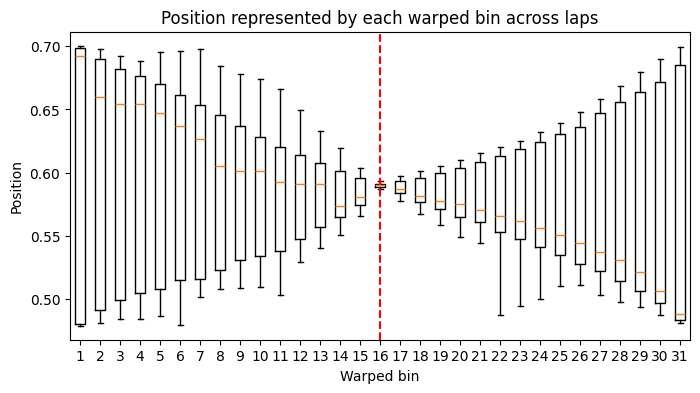

/tmp/ipykernel_71971/3219911592.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap("magma").copy()


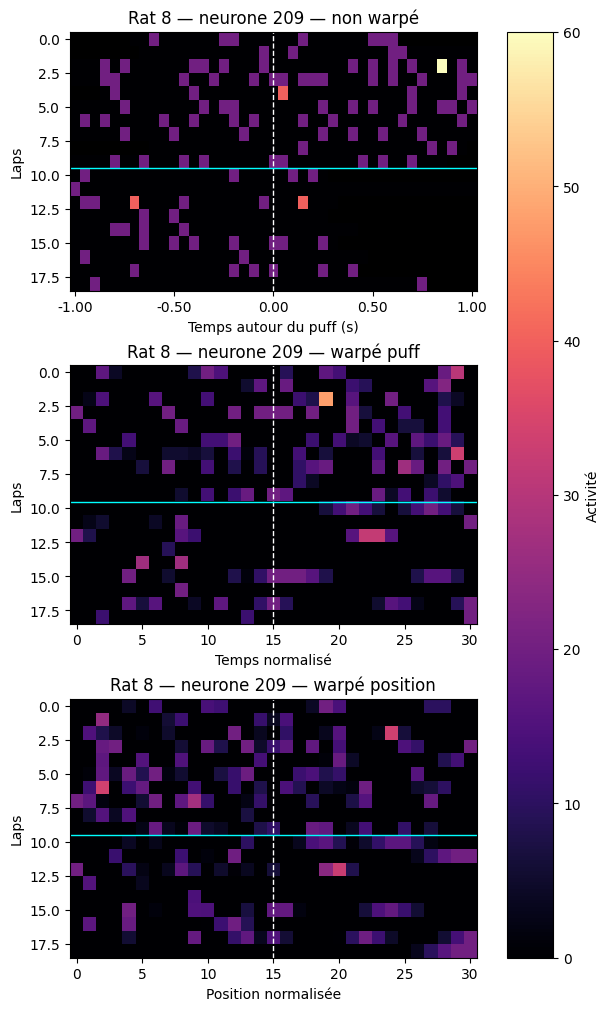

In [9]:
data_8 = scipy.io.loadmat('../data/Rat8-20130713_proces_bin5.mat')
data_11 = scipy.io.loadmat('../data/Rat11-20150327_proces_bin5.mat')

X_tensor, info_tensor = build_warped_lap_tensor(
    data_8,
    session="run",
    dt_ms=50,
    use_regions="HB",
    excit_only=True,
    restrict_to_puff_zone=True,
    n_time_bins=31,
    warp_mode="puff_time",
)

plot_warped_bin_positions(info_tensor)

plot_three_pellegrino_style(
    data_full=data_8,
    neuron_idx=209,
    session="run",
    dt_ms=50,
    halfwidth_cm=20,
    n_time_bins=31,
    t_before_s=1.0,
    t_after_s=1.0,
    rat_name="Rat 8",
)

M = tensor_to_neuron_slicing(X_tensor)
W, H, model = run_nmf(M, n_components=5, seed=0)